Chi Square and Fisher's Exact Test on the Cleaned Review Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import expected_freq
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Libraries imported successfully!


In [6]:
# Load the cleaned data
df = pd.read_csv('../data/Review_SY-08002944_4_3_2025 10_31_21_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTotal samples: {len(df)}")
print(f"\nColumn names:")
print(df.columns.tolist())

print("First  rows:")
display(df.head())

Dataset shape: (25, 42)

Total samples: 25

Column names:
['Sample ID', 'Patient ID', 'Patient', 'WBC (10^3/uL)', 'Neu # (10^3/uL)', 'Lym # (10^3/uL)', 'Mon # (10^3/uL)', 'Eos # (10^3/uL)', 'Bas # (10^3/uL)', 'Neu % (%)', 'Lym % (%)', 'Mon % (%)', 'Eos % (%)', 'Bas % (%)', 'RBC (10^6/uL)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)', 'MCH (pg)', 'MCHC (g/dL)', 'RDW-CV (%)', 'PLT (10^3/uL)', 'MPV (fL)', 'Species', 'Sample State', 'Owner Last Name', 'Mode', 'Date', 'Time', 'Gender', 'Age', 'Ref. Group', 'Draw Date', 'Draw Time', 'Delivery Date', 'Delivery Time', 'Veterinarian', 'Operator', 'Comments', 'WBC Message', 'RBC Message', 'PLT Message']
First  rows:


,Sample ID,Patient ID,Patient,WBC (10^3/uL),Neu # (10^3/uL),Lym # (10^3/uL),Mon # (10^3/uL),Eos # (10^3/uL),Bas # (10^3/uL),Neu % (%),...,Draw Date,Draw Time,Delivery Date,Delivery Time,Veterinarian,Operator,Comments,WBC Message,RBC Message,PLT Message
0,5410,NaN,NaN,H 13.42,2.50,H 9.81,0.66,0.34,0.11,18.7,...,NaN,NaN,NaN,NaN,NaN,Schuettpelz,NaN,Leukocytosis,NaN,NaN
1,5409,NaN,NaN,H 11.14,1.41,H 8.99,0.50,0.18,0.06,12.7,...,NaN,NaN,NaN,NaN,NaN,Schuettpelz,NaN,NaN,NaN,NaN
2,5408,NaN,NaN,H 12.75,2.46,H 9.14,0.84,0.22,0.09,19.3,...,NaN,NaN,NaN,NaN,NaN,Schuettpelz,NaN,Leukocytosis,NaN,NaN
3,5407,NaN,NaN,H 13.50,3.31,H 9.56,0.41,0.13,0.09,24.5,...,NaN,NaN,NaN,NaN,NaN,Schuettpelz,NaN,Leukocytosis,NaN,NaN
4,5406,NaN,NaN,H 20.72,H 4.26,H 14.39,H 1.60,0.36,0.11,20.6,...,NaN,NaN,NaN,NaN,NaN,Schuettpelz,NaN,Leukocytosis\nLymphocytosis,NaN,NaN


In [ ]:
# Clean categorical variables

# Replace empty strings with 'Normal' for message columns
df['WBC Message'] = df['WBC Message'].replace('', 'Normal').fillna('Normal')
df['RBC Message'] = df['RBC Message'].replace('', 'Normal').fillna('Normal')
df['PLT Message'] = df['PLT Message'].replace('', 'Normal').fillna('Normal')

# Clean operator column
df['Operator'] = df['Operator'].fillna('Unknown')

# Remove TEST sample if it exists
df = df[df['Sample ID'] != 'TEST'].copy()

print("✓ Data cleaned!")
print(f"\nRemaining samples: {len(df)}")

# Display distribution of all categorical variables
print("\n" + "="*70)
print("CATEGORICAL VARIABLE DISTRIBUTIONS")
print("="*70)

print(df['Operator'].value_counts())

print(df['WBC Message'].value_counts())

print(df['RBC Message'].value_counts())

print(df['PLT Message'].value_counts())

✓ Data cleaned!

Remaining samples: 24

CATEGORICAL VARIABLE DISTRIBUTIONS

Operator:
Operator
Schuettpelz    20
Magee           4
Name: count, dtype: int64


WBC Message:
WBC Message
Normal                                    9
Leukocytosis                              7
Leukocytosis\nLymphocytosis               5
Leukopenia\nNeutropenia\nLymphopenia      1
Leukocytosis\nBasophilia\nEosinophilia    1
Basophilia                                1
Name: count, dtype: int64


RBC Message:
RBC Message
Normal          19
Anemia           4
Microcytosis     1
Name: count, dtype: int64


PLT Message:
PLT Message
Normal              20
Thrombocytopenia     4
Name: count, dtype: int64


In [11]:
# Cell 4: Helper functions for statistical tests

"""
The Chi-Square test is based on an **approximation** that works well when sample sizes are large enough. Specifically:

Chi-Square assumes that the expected frequencies follow a continuous distribution (chi-squared distribution)**

But when expected frequencies are **too small** (< 5), this approximation **breaks down** and becomes **unreliable**.

Then we use Fisher's Exact Test to handle the less frequent samples

"""
def perform_chi_square_test(contingency_table, test_name):
    """
    Perform Chi-Square test and return formatted results
    """
    print(f"\n{'='*70}")
    print(f"CHI-SQUARE TEST: {test_name}")
    print(f"{'='*70}")
    
    # Display contingency table
    print("\nContingency Table:")
    print(contingency_table)
    print(f"\nTable shape: {contingency_table.shape}")
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Display expected frequencies
    print("\n\nExpected Frequencies:")
    expected_df = pd.DataFrame(
        expected, 
        index=contingency_table.index, 
        columns=contingency_table.columns
    )
    print(expected_df.round(2))
    
    # Check if expected frequencies are adequate (all >= 5)
    min_expected = expected.min()
    adequate = min_expected >= 5
    
    # Results
    print(f"\n\nSTATISTICS:")
    print(f"  χ² statistic: {chi2:.4f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Minimum expected frequency: {min_expected:.2f}")
    
    #if the a certain sample size frequency is too small, use Fisher's Exact Test
    if not adequate:
        print(f"\n  ⚠️  WARNING: Some expected frequencies < 5")
        print(f"     Chi-square may not be reliable. Consider Fisher's Exact Test if 2x2.")
    
    # Interpretation
    print(f"\n\nINTERPRETATION:")
    if p_value < 0.05:
        print(f"  ✓ p < 0.05: SIGNIFICANT ASSOCIATION")
        print(f"    There IS a statistically significant association between the variables.")
    else:
        print(f"  ✗ p ≥ 0.05: NO SIGNIFICANT ASSOCIATION")
        print(f"    There is NO statistically significant association between the variables.")
    
    return {
        'test_name': test_name,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'expected': expected,
        'adequate': adequate
    }


def perform_fisher_exact_test(contingency_table, test_name):
    """
    Perform Fisher's Exact test for 2x2 tables
    """
    print(f"\n{'='*70}")
    print(f"FISHER'S EXACT TEST: {test_name}")
    print(f"{'='*70}")
    
    if contingency_table.shape != (2, 2):
        print(f"\n⚠️  Fisher's Exact Test requires a 2x2 table.")
        print(f"   Current table is {contingency_table.shape}")
        print(f"   Skipping this test.")
        return None
    
    # Display contingency table
    print("\nContingency Table (2x2):")
    print(contingency_table)
    
    # Perform Fisher's exact test
    oddsratio, p_value = fisher_exact(contingency_table)
    
    # Results
    print(f"\n\nSTATISTICS:")
    print(f"  Odds Ratio: {oddsratio:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    # Interpretation
    print(f"\n\nINTERPRETATION:")
    if p_value < 0.05:
        print(f"  ✓ p < 0.05: SIGNIFICANT ASSOCIATION")
        print(f"    There IS a statistically significant association between the variables.")
    else:
        print(f"  ✗ p ≥ 0.05: NO SIGNIFICANT ASSOCIATION")
        print(f"    There is NO statistically significant association between the variables.")
    
    return {
        'test_name': test_name,
        'odds_ratio': oddsratio,
        'p_value': p_value
    }

In [12]:
# Visualization functions

def plot_contingency_table(contingency_table, test_name, p_value):
    """
    Create visualizations for contingency table
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Heatmap of counts
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', 
                cbar_kws={'label': 'Count'}, ax=axes[0], linewidths=0.5, linecolor='gray')
    axes[0].set_title(f'{test_name}\nFrequency Heatmap', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(contingency_table.columns.name or 'Column Variable', fontsize=12)
    axes[0].set_ylabel(contingency_table.index.name or 'Row Variable', fontsize=12)
    
    # 2. Stacked bar chart (proportions)
    contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
    contingency_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                         colormap='Set3', edgecolor='black', linewidth=0.7)
    axes[1].set_title(f'{test_name}\nProportional Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(contingency_table.index.name or 'Row Variable', fontsize=12)
    axes[1].set_ylabel('Percentage (%)', fontsize=12)
    axes[1].legend(title=contingency_table.columns.name or 'Column Variable', 
                   bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_ylim([0, 100])
    
    # Add p-value to plot
    significance = "SIGNIFICANT ✓" if p_value < 0.05 else "NOT SIGNIFICANT ✗"
    color = 'green' if p_value < 0.05 else 'red'
    fig.suptitle(f'p-value = {p_value:.4f} ({significance})', 
                 fontsize=13, y=1.02, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.show()


ANALYSIS 1: OPERATOR vs WBC MESSAGE

CHI-SQUARE TEST: Operator vs WBC Message

Contingency Table:
WBC Message  Basophilia  Leukocytosis  Leukocytosis\nBasophilia\nEosinophilia  \
Operator                                                                        
Magee                 0             0                                       1   
Schuettpelz           1             7                                       0   

WBC Message  Leukocytosis\nLymphocytosis  \
Operator                                   
Magee                                  1   
Schuettpelz                            4   

WBC Message  Leukopenia\nNeutropenia\nLymphopenia  Normal  
Operator                                                   
Magee                                           0       2  
Schuettpelz                                     1       7  

Table shape: (2, 6)


Expected Frequencies:
WBC Message  Basophilia  Leukocytosis  Leukocytosis\nBasophilia\nEosinophilia  \
Operator                          

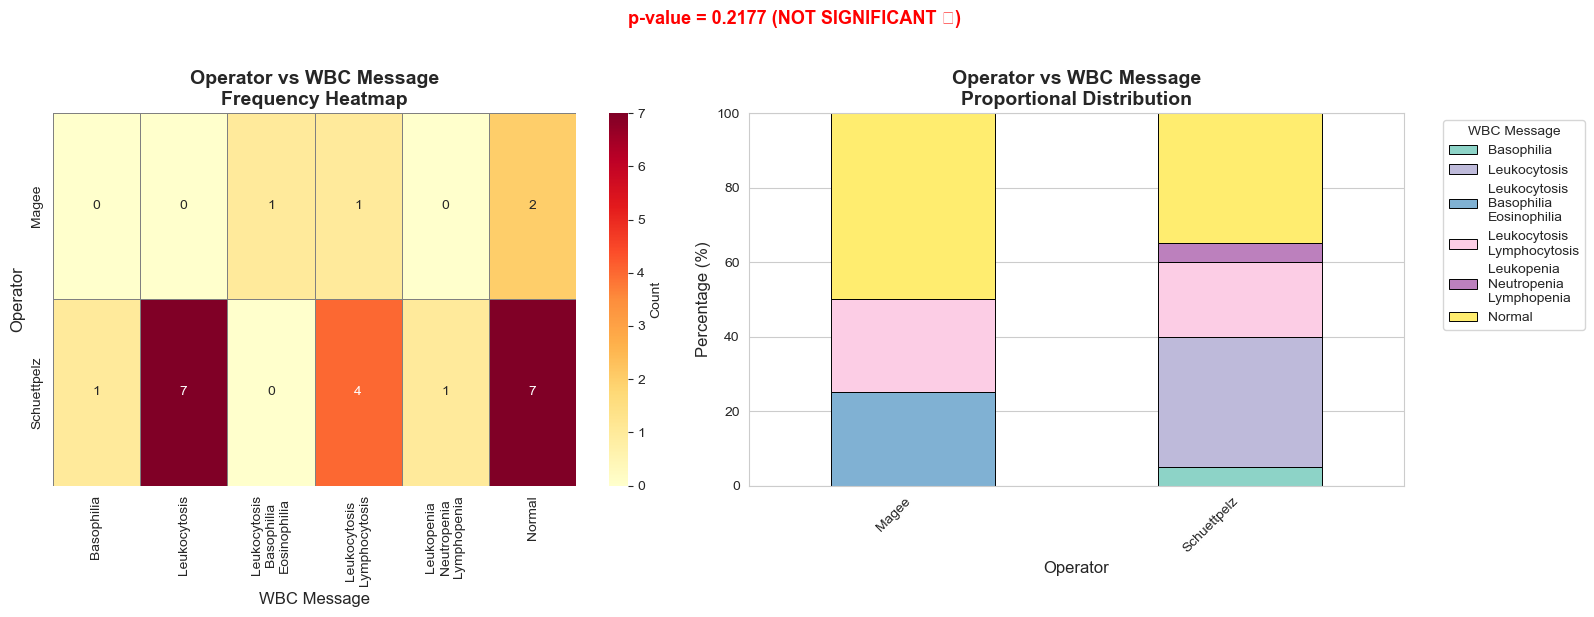

In [14]:
# Analysis 1 - Operator vs WBC Message

print("ANALYSIS 1: OPERATOR vs WBC MESSAGE")

# Create contingency table
ct_1 = pd.crosstab(
    df['Operator'], 
    df['WBC Message'],
    margins=False
)

# Perform Chi-Square test
result_1 = perform_chi_square_test(ct_1, "Operator vs WBC Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_1.shape == (2, 2):
    fisher_1 = perform_fisher_exact_test(ct_1, "Operator vs WBC Message")

# Visualize
plot_contingency_table(ct_1, "Operator vs WBC Message", result_1['p_value'])


🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
ANALYSIS 2: OPERATOR vs RBC MESSAGE
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

CHI-SQUARE TEST: Operator vs RBC Message

Contingency Table:
RBC Message  Anemia  Microcytosis  Normal
Operator                                 
Magee             0             1       3
Schuettpelz       4             0      16

Table shape: (2, 3)


Expected Frequencies:
RBC Message  Anemia  Microcytosis  Normal
Operator                                 
Magee          0.67          0.17    3.17
Schuettpelz    3.33          0.83   15.83


STATISTICS:
  χ² statistic: 5.8105
  Degrees of freedom: 2
  p-value: 0.0547
  Minimum expected frequency: 0.17

  ⚠️  WARNING: Some expected frequencies < 5
     Chi-square may not be reliable. Consider Fisher's Exact Test if 2x2.


INTERPRETATION:
  ✗ p ≥ 0.05: NO SIGNIFICANT ASSOCIATION
    There is NO statistically significant association between the variables.


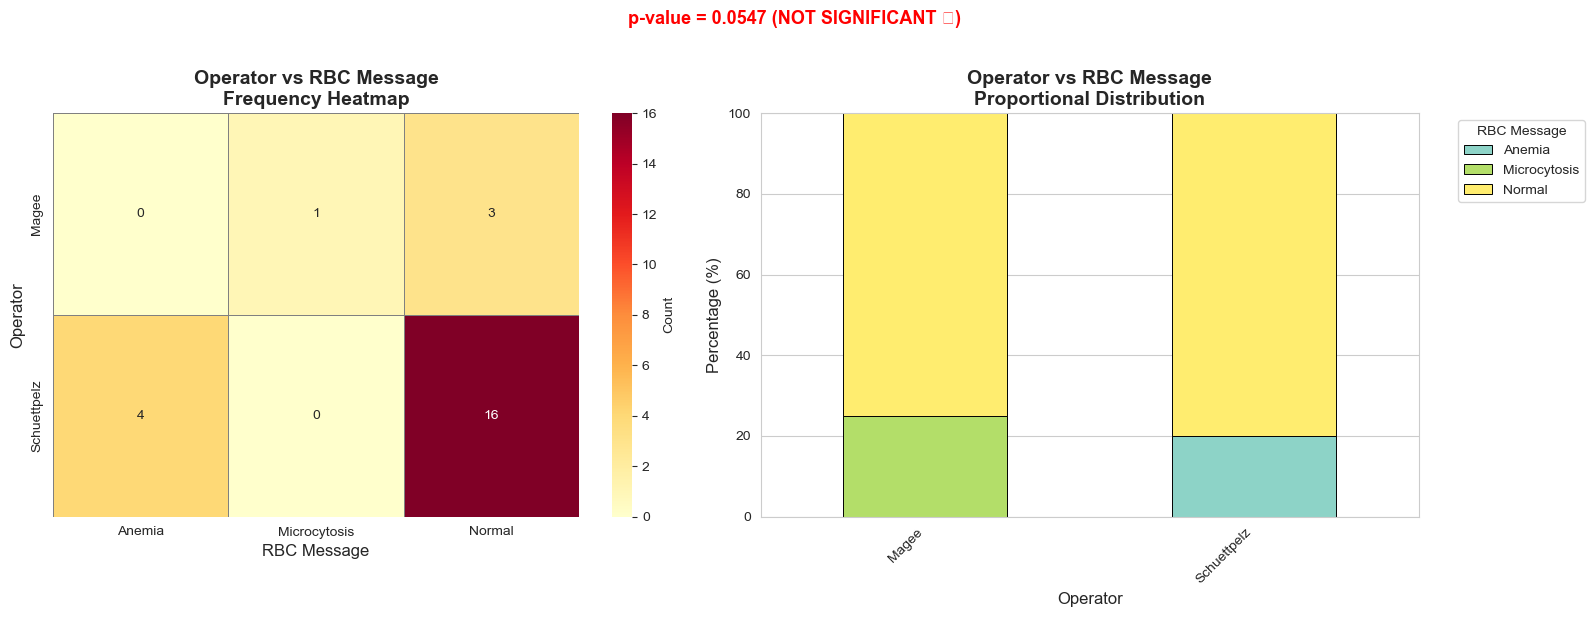

In [ ]:
# Analysis 2 - Operator vs RBC Message

print("ANALYSIS 2: OPERATOR vs RBC MESSAGE")

# Create contingency table
ct_2 = pd.crosstab(
    df['Operator'], 
    df['RBC Message'],
    margins=False
)

# Perform Chi-Square test
result_2 = perform_chi_square_test(ct_2, "Operator vs RBC Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_2.shape == (2, 2):
    fisher_2 = perform_fisher_exact_test(ct_2, "Operator vs RBC Message")

# Visualize
plot_contingency_table(ct_2, "Operator vs RBC Message", result_2['p_value'])

ANALYSIS 3: OPERATOR vs PLT MESSAGE

CHI-SQUARE TEST: Operator vs PLT Message

Contingency Table:
PLT Message  Normal  Thrombocytopenia
Operator                             
Magee             4                 0
Schuettpelz      16                 4

Table shape: (2, 2)


Expected Frequencies:
PLT Message  Normal  Thrombocytopenia
Operator                             
Magee          3.33              0.67
Schuettpelz   16.67              3.33


STATISTICS:
  χ² statistic: 0.0600
  Degrees of freedom: 1
  p-value: 0.8065
  Minimum expected frequency: 0.67

  ⚠️  WARNING: Some expected frequencies < 5
     Chi-square may not be reliable. Consider Fisher's Exact Test if 2x2.


INTERPRETATION:
  ✗ p ≥ 0.05: NO SIGNIFICANT ASSOCIATION
    There is NO statistically significant association between the variables.

FISHER'S EXACT TEST: Operator vs PLT Message

Contingency Table (2x2):
PLT Message  Normal  Thrombocytopenia
Operator                             
Magee             4                

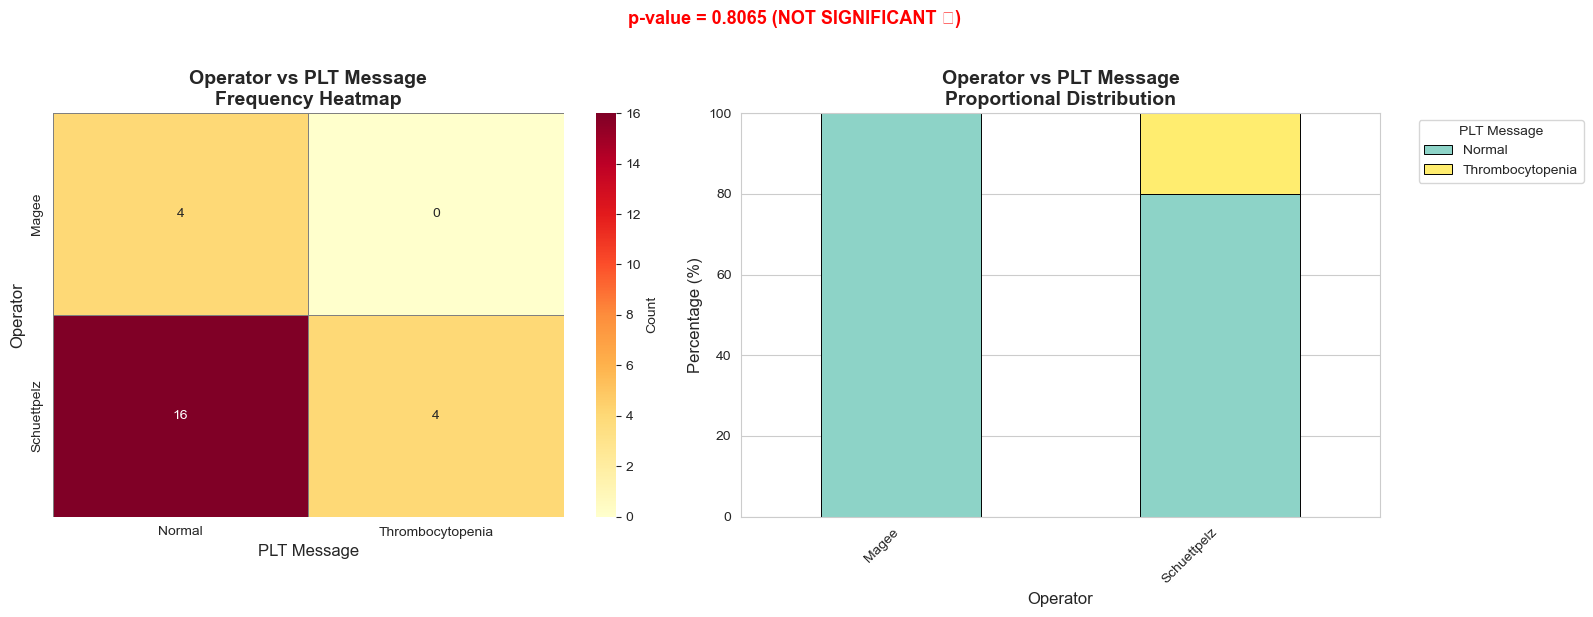

In [16]:
# Analysis 3 - Operator vs PLT Message

print("ANALYSIS 3: OPERATOR vs PLT MESSAGE")

# Create contingency table
ct_3 = pd.crosstab(
    df['Operator'], 
    df['PLT Message'],
    margins=False
)

# Perform Chi-Square test
result_3 = perform_chi_square_test(ct_3, "Operator vs PLT Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_3.shape == (2, 2):
    fisher_3 = perform_fisher_exact_test(ct_3, "Operator vs PLT Message")

# Visualize
plot_contingency_table(ct_3, "Operator vs PLT Message", result_3['p_value'])

ANALYSIS 4: WBC MESSAGE vs RBC MESSAGE

CHI-SQUARE TEST: WBC Message vs RBC Message

Contingency Table:
RBC Message                             Anemia  Microcytosis  Normal
WBC Message                                                         
Basophilia                                   1             0       0
Leukocytosis                                 0             0       7
Leukocytosis\nBasophilia\nEosinophilia       0             1       0
Leukocytosis\nLymphocytosis                  0             0       5
Leukopenia\nNeutropenia\nLymphopenia         1             0       0
Normal                                       2             0       7

Table shape: (6, 3)


Expected Frequencies:
RBC Message                             Anemia  Microcytosis  Normal
WBC Message                                                         
Basophilia                                0.17          0.04    0.79
Leukocytosis                              1.17          0.29    5.54
Leukocytosis\nBasophili

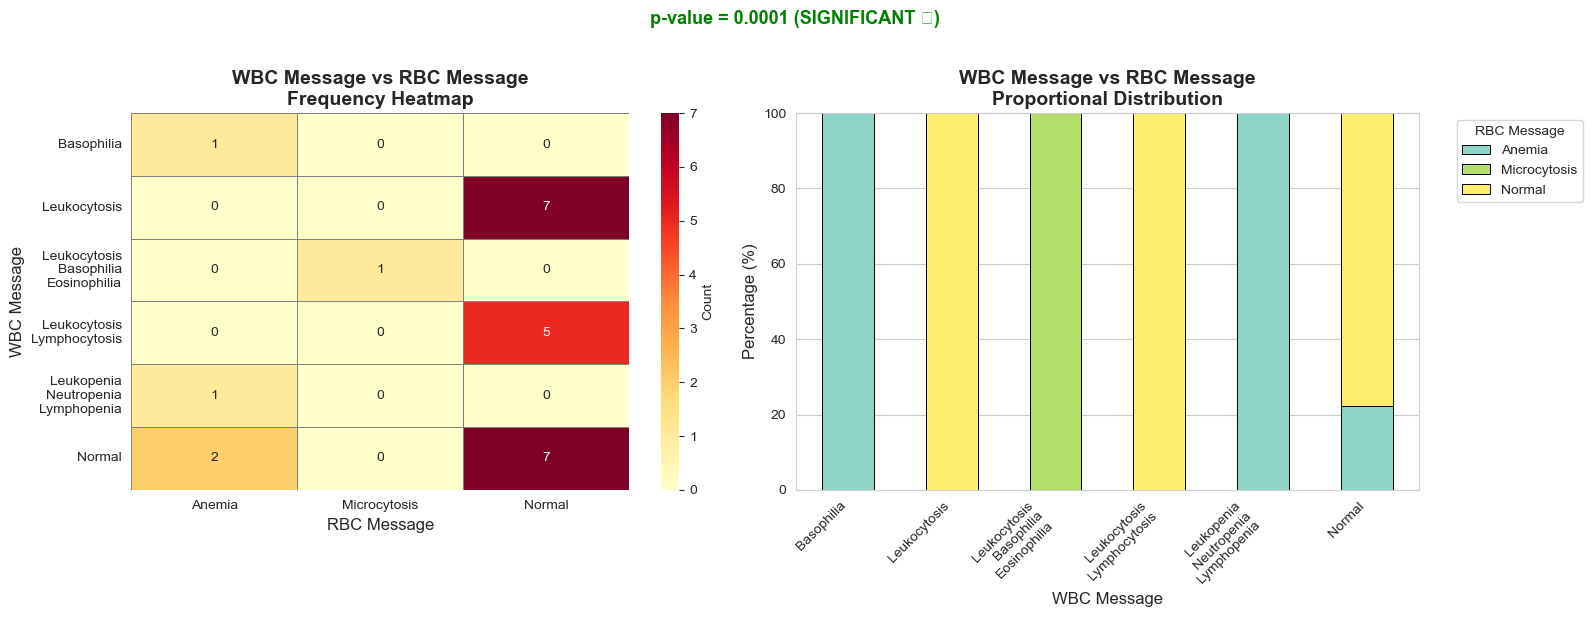

In [17]:
# Analysis 4 - WBC Message vs RBC Message

print("ANALYSIS 4: WBC MESSAGE vs RBC MESSAGE")

# Create contingency table
ct_4 = pd.crosstab(
    df['WBC Message'], 
    df['RBC Message'],
    margins=False
)

# Perform Chi-Square test
result_4 = perform_chi_square_test(ct_4, "WBC Message vs RBC Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_4.shape == (2, 2):
    fisher_4 = perform_fisher_exact_test(ct_4, "WBC Message vs RBC Message")

# Visualize
plot_contingency_table(ct_4, "WBC Message vs RBC Message", result_4['p_value'])

ANALYSIS 5: WBC MESSAGE vs PLT MESSAGE

CHI-SQUARE TEST: WBC Message vs PLT Message

Contingency Table:
PLT Message                             Normal  Thrombocytopenia
WBC Message                                                     
Basophilia                                   0                 1
Leukocytosis                                 7                 0
Leukocytosis\nBasophilia\nEosinophilia       1                 0
Leukocytosis\nLymphocytosis                  5                 0
Leukopenia\nNeutropenia\nLymphopenia         0                 1
Normal                                       7                 2

Table shape: (6, 2)


Expected Frequencies:
PLT Message                             Normal  Thrombocytopenia
WBC Message                                                     
Basophilia                                0.83              0.17
Leukocytosis                              5.83              1.17
Leukocytosis\nBasophilia\nEosinophilia    0.83              0.17
Leukoc

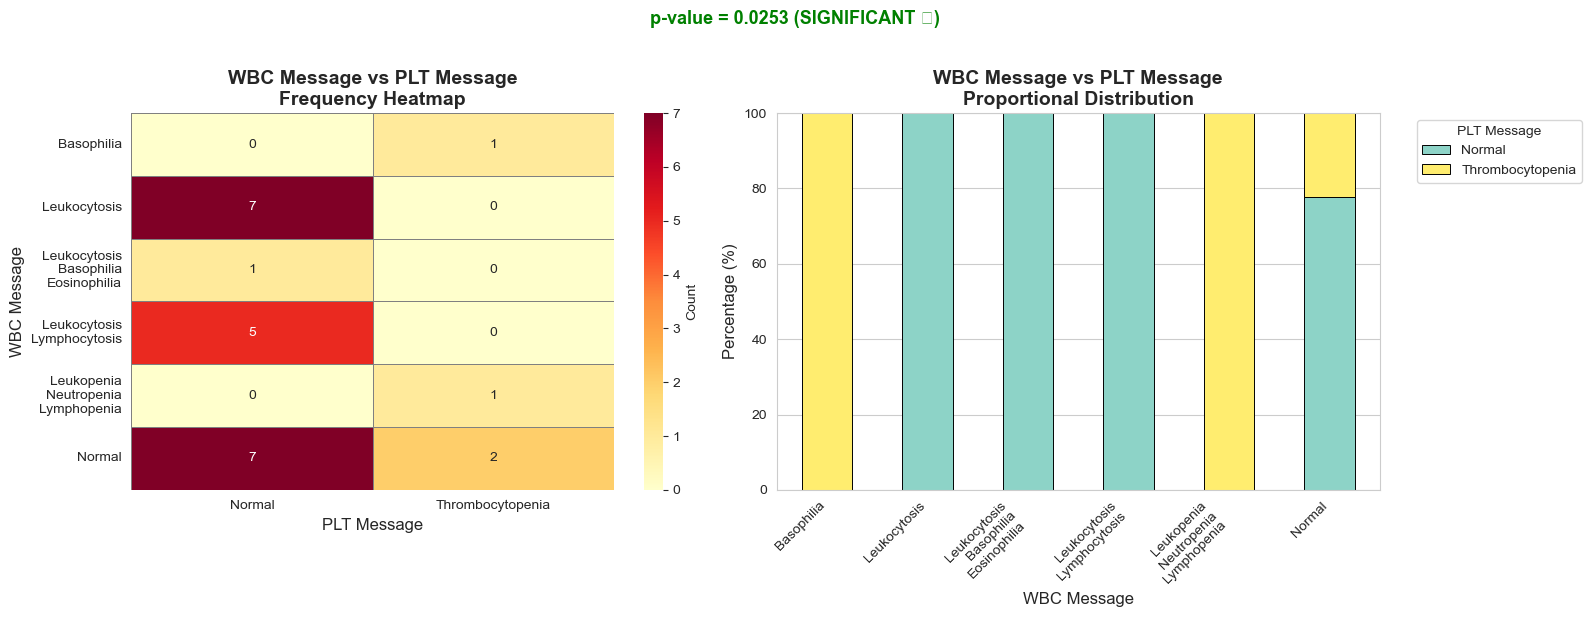

In [19]:
# Analysis 5 - WBC Message vs PLT Message

print("ANALYSIS 5: WBC MESSAGE vs PLT MESSAGE")

# Create contingency table
ct_5 = pd.crosstab(
    df['WBC Message'], 
    df['PLT Message'],
    margins=False
)

# Perform Chi-Square test
result_5 = perform_chi_square_test(ct_5, "WBC Message vs PLT Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_5.shape == (2, 2):
    fisher_5 = perform_fisher_exact_test(ct_5, "WBC Message vs PLT Message")

# Visualize
plot_contingency_table(ct_5, "WBC Message vs PLT Message", result_5['p_value'])

ANALYSIS 6: RBC MESSAGE vs PLT MESSAGE

CHI-SQUARE TEST: RBC Message vs PLT Message

Contingency Table:
PLT Message   Normal  Thrombocytopenia
RBC Message                           
Anemia             0                 4
Microcytosis       1                 0
Normal            19                 0

Table shape: (3, 2)


Expected Frequencies:
PLT Message   Normal  Thrombocytopenia
RBC Message                           
Anemia          3.33              0.67
Microcytosis    0.83              0.17
Normal         15.83              3.17


STATISTICS:
  χ² statistic: 24.0000
  Degrees of freedom: 2
  p-value: 0.0000
  Minimum expected frequency: 0.17

  ⚠️  WARNING: Some expected frequencies < 5
     Chi-square may not be reliable. Consider Fisher's Exact Test if 2x2.


INTERPRETATION:
  ✓ p < 0.05: SIGNIFICANT ASSOCIATION
    There IS a statistically significant association between the variables.


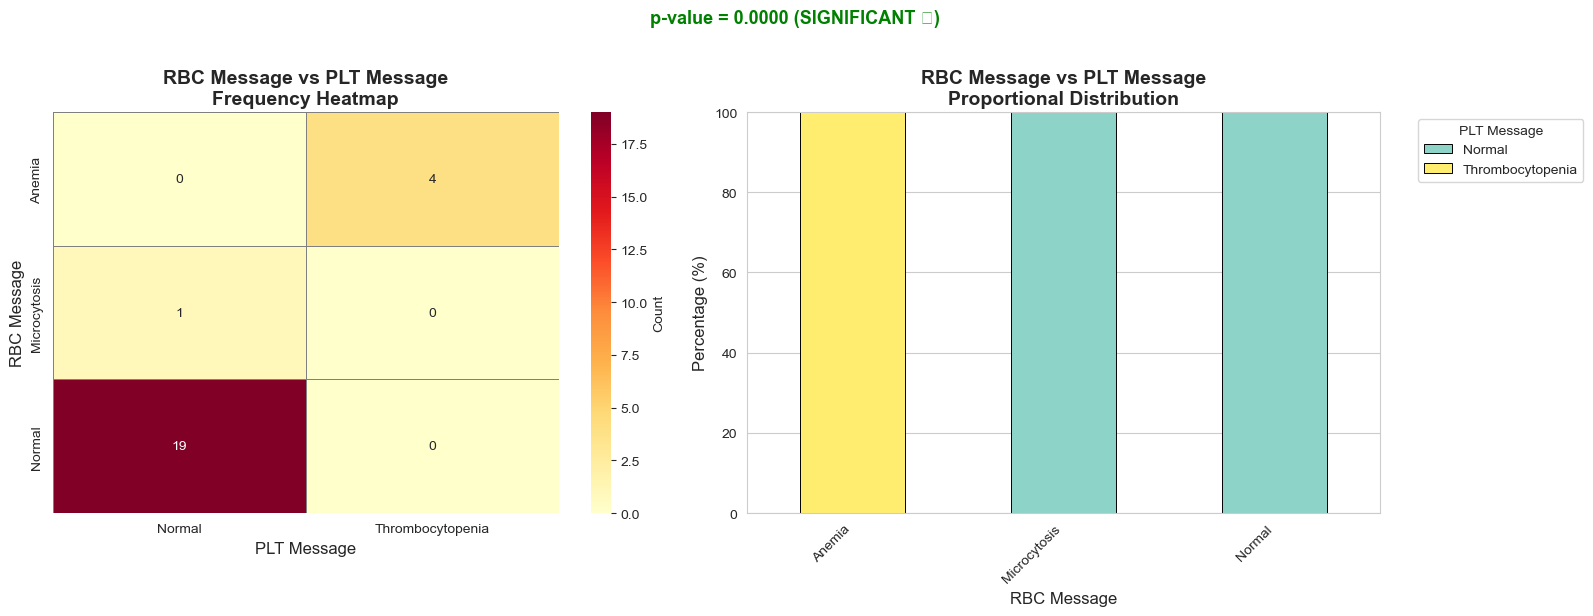

In [20]:
# Analysis 6 - RBC Message vs PLT Message

print("ANALYSIS 6: RBC MESSAGE vs PLT MESSAGE")

# Create contingency table
ct_6 = pd.crosstab(
    df['RBC Message'], 
    df['PLT Message'],
    margins=False
)

# Perform Chi-Square test
result_6 = perform_chi_square_test(ct_6, "RBC Message vs PLT Message")

# If it's a 2x2 table, also perform Fisher's test
if ct_6.shape == (2, 2):
    fisher_6 = perform_fisher_exact_test(ct_6, "RBC Message vs PLT Message")

# Visualize
plot_contingency_table(ct_6, "RBC Message vs PLT Message", result_6['p_value'])

In [22]:
#  Summary of All Statistical Tests

print("SUMMARY OF ALL STATISTICAL TESTS")

# Collect all results
all_results = [result_1, result_2, result_3, result_4, result_5, result_6]

# Create summary dataframe
summary_data = {
    'Test': [r['test_name'] for r in all_results],
    'χ² Statistic': [f"{r['chi2']:.4f}" for r in all_results],
    'df': [r['dof'] for r in all_results],
    'p-value': [f"{r['p_value']:.4f}" for r in all_results],
    'Significant (p<0.05)': ['✓ Yes' if r['p_value'] < 0.05 else '✗ No' for r in all_results],
    'Expected Freq OK': ['✓ Yes' if r['adequate'] else '⚠️ No' for r in all_results]
}

summary_df = pd.DataFrame(summary_data)

print("\n")
display(summary_df)


SUMMARY OF ALL STATISTICAL TESTS




,Test,χ² Statistic,df,p-value,Significant (p<0.05),Expected Freq OK
0,Operator vs WBC Message,7.0400,5,0.2177,✗ No,⚠️ No
1,Operator vs RBC Message,5.8105,2,0.0547,✗ No,⚠️ No
2,Operator vs PLT Message,0.0600,1,0.8065,✗ No,⚠️ No
3,WBC Message vs RBC Message,36.7018,10,0.0001,✓ Yes,⚠️ No
4,WBC Message vs PLT Message,12.8000,5,0.0253,✓ Yes,⚠️ No
5,RBC Message vs PLT Message,24.0000,2,0.0000,✓ Yes,⚠️ No


In [26]:
# Possible Clinical Interpretation and Conclusions

print("CLINICAL INTERPRETATION")

print("""
QUALITY CONTROL FINDINGS:
-------------------------
Tests 1-3 assess whether different operators (Schuettpelz vs Magee) report 
different patterns of blood abnormalities:

1. Operator vs WBC Message
    Checks for operator bias in white blood cell abnormality reporting

2. Operator vs RBC Message
    Checks for operator bias in red blood cell abnormality reporting

3. Operator vs PLT Message
    Checks for operator bias in platelet abnormality reporting

CLINICAL PATTERN FINDINGS:
--------------------------
Tests 4-6 examine associations between different types of blood abnormalities:

4. WBC Message vs RBC Message
    Are white blood cell and red blood cell abnormalities associated?

5. WBC Message vs PLT Message
    Are white blood cell and platelet abnormalities associated?

6. RBC Message vs PLT Message
    Are red blood cell and platelet abnormalities associated?

""")

# Determine significant findings
significant_tests = [r for r in all_results if r['p_value'] < 0.05]

print("KEY FINDINGS:")
print("=" * 70)

if significant_tests:
    print(f"\n✓ Significant associations found in {len(significant_tests)} out of 6 tests:\n")
    for result in significant_tests:
        print(f"  • {result['test_name']}")
        print(f"    χ² = {result['chi2']:.4f}, p = {result['p_value']:.4f}")
        print()
else:
    print("\n✗ No significant associations found in any test.")
    print("  All variables appear to be independent of each other.")

CLINICAL INTERPRETATION

QUALITY CONTROL FINDINGS:
-------------------------
Tests 1-3 assess whether different operators (Schuettpelz vs Magee) report 
different patterns of blood abnormalities:

1. Operator vs WBC Message
    Checks for operator bias in white blood cell abnormality reporting

2. Operator vs RBC Message
    Checks for operator bias in red blood cell abnormality reporting

3. Operator vs PLT Message
    Checks for operator bias in platelet abnormality reporting

CLINICAL PATTERN FINDINGS:
--------------------------
Tests 4-6 examine associations between different types of blood abnormalities:

4. WBC Message vs RBC Message
    Are white blood cell and red blood cell abnormalities associated?

5. WBC Message vs PLT Message
    Are white blood cell and platelet abnormalities associated?

6. RBC Message vs PLT Message
    Are red blood cell and platelet abnormalities associated?


KEY FINDINGS:

✓ Significant associations found in 3 out of 6 tests:

  • WBC Message vs RBC